In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
from sklearn.preprocessing import MaxAbsScaler
from sklearn.svm import SVR
from tensorflow.keras.layers import GRU, LSTM, Dense, Dropout
from itertools import combinations

In [2]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

In [3]:
data

,Date,Avg_Usr,Avg_Usr_TP_DL,Avg_Usr_TP_UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,DL_TRAFFIC_MB,Max_Usr,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
0,1-Sep-22,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848,251968.1429,393.651786,32890183.17,37.050402,4142157.11
1,2-Sep-22,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2,3-Sep-22,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565,246798.6027,388.062500,33383868.74,36.708884,4281017.27
3,4-Sep-22,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303,257327.6563,387.245536,32606986.82,36.628527,4140106.66
4,5-Sep-22,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,28-Aug-23,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
362,29-Aug-23,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
363,30-Aug-23,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111,133872.1556,362.741936,65854384.38,40.078159,7464569.80
364,31-Aug-23,23803.97,7.090190,0.510664,99.661120,0.809222,7.563378,0.088520,38.284099,59759544.72,51682,134106.0171,0.000000,67421649.20,39.138444,7662104.58


In [4]:
data.columns

Index(['Date', 'Avg_Usr', 'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR',
       'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE',
       'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 'S1_SIG_SUCC',
       'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'],
      dtype='object')

In [6]:
# List of potential features to use for multivariate analysis
all_features = ['Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 'DL_256QAM_PROPORTION',
                'DL_LATENCY', 'DL_PACK_LOSS_RATE', 'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 
                'Max_Usr', 'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 
                'UL_TRAFFIC_MB']

In [7]:
# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + all_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]


In [8]:
# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is Avg_Usr (first column after scaling)
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

In [9]:
# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature combination
mse_scores = {}

In [16]:
# Iterate over different combinations of features
for i in range(1, len(all_features) + 1):
    for feature_comb in combinations(all_features, i):
        # Prepare data with selected features
        selected_features = [target_feature] + list(feature_comb)
        feature_indices = [data.columns.get_loc(f) for f in selected_features]
        
        train_data_selected = train_data[:, feature_indices]
        test_data_selected = test_data[:, feature_indices]
        
        # Create dataset for GRU
        X_train, y_train = create_dataset(train_data_selected, look_back=look_back)
        X_test, y_test = create_dataset(test_data_selected, look_back=look_back)
        
        # Reshape input data to 3D (samples, timesteps, features) for GRU input
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], len(feature_comb) + 1))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], len(feature_comb) + 1))
        
        # Train GRU model
        model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
        
        # Calculate MSE
        mse = mean_squared_error(y_test, test_predict)
        mse_scores[feature_comb] = mse
        print(f'Features: {feature_comb}, MSE: {mse}')

3/3 [==============================] - 1s 3ms/step
Features: ('Avg_Usr_TP_DL',), MSE: 0.006574869124757399
3/3 [==============================] - 1s 3ms/step
Features: ('Avg_Usr_TP_UL',), MSE: 0.014255380358740083
3/3 [==============================] - 1s 3ms/step
Features: ('CSSR',), MSE: 0.012125692598425069
3/3 [==============================] - 1s 2ms/step
Features: ('DL_256QAM_PROPORTION',), MSE: 0.021859409620801195
3/3 [==============================] - 1s 2ms/step
Features: ('DL_LATENCY',), MSE: 0.005074480306087444
3/3 [==============================] - 1s 3ms/step
Features: ('DL_PACK_LOSS_RATE',), MSE: 0.0036486142351686225
3/3 [==============================] - 1s 2ms/step
Features: ('DL_QPSK_PROPORTION',), MSE: 0.00646577484355463
3/3 [==============================] - 1s 5ms/step
Features: ('DL_TRAFFIC_MB',), MSE: 0.008349676090636629
3/3 [==============================] - 1s 3ms/step
Features: ('Max_Usr',), MSE: 0.0061833447317497315
3/3 [==============================] -

IndexError: index 15 is out of bounds for axis 1 with size 15

In [12]:
data.columns

Index(['Date', 'Avg_Usr', 'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR',
       'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE',
       'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 'S1_SIG_SUCC',
       'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'],
      dtype='object')

In [3]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]

# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 3s 8ms/step
                    Features       MSE
0                 DL_LATENCY  0.005487
1              Avg_Usr_TP_UL  0.006116
2       DL_256QAM_PROPORTION  0.006225
3              Avg_Usr_TP_DL  0.006400
4              DL_TRAFFIC_MB  0.007529
5                       CSSR  0.010082
6          DL_PACK_LOSS_RATE  0.011493
7         DL_QPSK_PROPORTION  0.014507
8                S1_SIG_SUCC  0.021112
9                    Max_Usr  0.025195
10  All 10 Features Combined  0.093235


In [5]:
from sklearn.metrics import r2_score
# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE and R-squared
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE and R-squared
mse = mean_squared_error(y_test, test_predict)
r_squared = r2_score(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse, "R-squared": r_squared})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 2s 3ms/step
                    Features       MSE  R-squared
0                 DL_LATENCY  0.005487        NaN
1              Avg_Usr_TP_UL  0.006116        NaN
2       DL_256QAM_PROPORTION  0.006225        NaN
3              Avg_Usr_TP_DL  0.006400        NaN
4       DL_256QAM_PROPORTION  0.006657   0.103991
5              DL_TRAFFIC_MB  0.006712   0.096526
6              Avg_Usr_TP_UL  0.007286   0.019350
7              DL_TRAFFIC_MB  0.007529        NaN
8   All 10 Features Combined  0.009588  -0.290526
9                       CSSR  0.010082        NaN
10         DL_PACK_LOSS_RATE  0.011493        NaN
11                   Max_Usr  0.012275  -0.652255
12               S1_SIG_SUCC  0.012751  -0.716306
13                      CSSR  0.013486  -0.815237
14             Avg_Usr_TP_DL  0.013650  -0.837286
15        DL_QPSK_PROPORTION  0.014507        NaN
16                DL_LATENCY  0.015386  -1.070929
17        DL_QPSK_PROPORTION  0.016206  -1.181365

In [14]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 1s 4ms/step
                    Features       MSE
0         UL_QPSK_PROPORTION  0.005294
1                    Traffic  0.005506
2              UL_TRAFFIC_MB  0.005603
3              Avg_Usr_TP_DL  0.005625
4         DL_QPSK_PROPORTION  0.005734
5              DL_TRAFFIC_MB  0.006208
6             TOTAL_DOWNTIME  0.006584
7                    Max_Usr  0.006990
8                 DL_LATENCY  0.010487
9                       CSSR  0.010846
10             Avg_Usr_TP_UL  0.011866
11      DL_256QAM_PROPORTION  0.012016
12         DL_PACK_LOSS_RATE  0.017575
13               S1_SIG_SUCC  0.025639
14  All 10 Features Combined  0.026557


In [15]:
# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'Avg_Usr_TP_DL'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 1s 2ms/step
                    Features       MSE
0                       CSSR  0.004213
1       DL_256QAM_PROPORTION  0.004233
2                    Traffic  0.005095
3          DL_PACK_LOSS_RATE  0.005615
4                    Avg_Usr  0.005652
5         UL_QPSK_PROPORTION  0.006775
6              Avg_Usr_TP_UL  0.008636
7                S1_SIG_SUCC  0.009100
8             TOTAL_DOWNTIME  0.010378
9              DL_TRAFFIC_MB  0.013540
10        DL_QPSK_PROPORTION  0.015366
11                   Max_Usr  0.018489
12             UL_TRAFFIC_MB  0.024419
13                DL_LATENCY  0.026149
14  All 10 Features Combined  0.089882


In [22]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# List of the first 10 features based on dataset
selected_features = [
    'Avg_Usr', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'Avg_Usr_TP_DL', 'Max_Usr', 
    'S1_SIG_SUCC', 'TOTAL_DOWNTIME', 'Traffic', 'UL_QPSK_PROPORTION', 'UL_TRAFFIC_MB'
]

# Target feature
target_feature = 'DL_TRAFFIC_MB'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for GRU
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train GRU model
def train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(GRU(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(GRU(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=14)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'rmsprop'
look_back = 3

# Dictionary to store MSE for each feature or combination
mse_scores = []

# Step 1: Train GRU model with each feature individually
for feature in selected_features:
    # Prepare data with the current single feature and target feature
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]
    
    # Create dataset for GRU
    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)
    
    # Reshape input data to 3D (samples, timesteps, features) for GRU input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))
    
    # Train GRU model
    model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
    
    # Calculate MSE
    mse = mean_squared_error(y_test, test_predict)
    mse_scores.append({"Features": feature, "MSE": mse})

# Step 2: Train GRU model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Create dataset for GRU with all 10 features
X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for GRU input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train GRU model
model, test_predict, history = train_gru_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Calculate MSE
mse = mean_squared_error(y_test, test_predict)
mse_scores.append({"Features": "All 10 Features Combined", "MSE": mse})

# Convert results to DataFrame and sort by MSE
mse_df = pd.DataFrame(mse_scores)
mse_df = mse_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(mse_df)

3/3 [==============================] - 2s 3ms/step
                    Features       MSE
0                 DL_LATENCY  0.002979
1          DL_PACK_LOSS_RATE  0.004257
2                    Traffic  0.004750
3                       CSSR  0.008330
4                S1_SIG_SUCC  0.008849
5         UL_QPSK_PROPORTION  0.010155
6                    Max_Usr  0.011293
7              Avg_Usr_TP_DL  0.011770
8              Avg_Usr_TP_UL  0.020315
9             TOTAL_DOWNTIME  0.020857
10                   Avg_Usr  0.026852
11      DL_256QAM_PROPORTION  0.034961
12        DL_QPSK_PROPORTION  0.041642
13             UL_TRAFFIC_MB  0.058369
14  All 10 Features Combined  0.078856


In [18]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Area3.csv')

In [21]:
data.columns

Index(['Date', 'AVG_NO_USER', 'AVG_USR_THRPUT_DL', 'DL_TRAFFIC_MB'], dtype='object')

Training with LSTM units=50, GRU units=50, dropout_rate=0.2, batch_size=32, epochs=50
Epoch 1/50
9/9 [==============================] - 12s 286ms/step - loss: 0.1335 - val_loss: 0.0399
Epoch 2/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0204 - val_loss: 0.0100
Epoch 3/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0216 - val_loss: 0.0013
Epoch 4/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0119 - val_loss: 0.0067
Epoch 5/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0098 - val_loss: 0.0014
Epoch 6/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0063 - val_loss: 0.0013
Epoch 7/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0048 - val_loss: 0.0014
Epoch 8/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 9/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0036 - val_loss: 0.0015
Epoch 10/50
9/9 [======================

5/5 [==============================] - 0s 14ms/step - loss: 0.0078 - val_loss: 0.0016
Epoch 12/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0064 - val_loss: 0.0014
Epoch 13/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0050 - val_loss: 0.0014
Epoch 14/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0041 - val_loss: 0.0015
Epoch 15/50
5/5 [==============================] - 0s 19ms/step - loss: 0.0043 - val_loss: 0.0015
Epoch 16/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 17/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0039 - val_loss: 0.0018
Epoch 18/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0042 - val_loss: 0.0016
Epoch 19/50
5/5 [==============================] - 0s 12ms/step - loss: 0.0035 - val_loss: 0.0016
Epoch 20/50
5/5 [==============================] - 0s 12ms/step - loss: 0.0038 - val_loss: 0.0015
Epoch 21/50
5/5 [===============

9/9 [==============================] - 0s 19ms/step - loss: 0.0038 - val_loss: 0.0015
Epoch 24/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 25/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0034 - val_loss: 0.0012
Epoch 26/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0032 - val_loss: 0.0013
Epoch 27/50
9/9 [==============================] - 0s 19ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 28/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0032 - val_loss: 0.0023
Epoch 29/50
9/9 [==============================] - 0s 16ms/step - loss: 0.0039 - val_loss: 0.0010
Epoch 30/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0031 - val_loss: 0.0011
Epoch 31/50
9/9 [==============================] - 0s 17ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 32/50
9/9 [==============================] - 0s 18ms/step - loss: 0.0032 - val_loss: 0.0010
Epoch 33/50
9/9 [===============

5/5 [==============================] - 0s 21ms/step - loss: 0.0040 - val_loss: 0.0016
Epoch 36/50
5/5 [==============================] - 0s 21ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 37/50
5/5 [==============================] - 0s 26ms/step - loss: 0.0042 - val_loss: 0.0013
Epoch 38/50
5/5 [==============================] - 0s 23ms/step - loss: 0.0041 - val_loss: 0.0013
Epoch 39/50
5/5 [==============================] - 0s 20ms/step - loss: 0.0043 - val_loss: 0.0013
Epoch 40/50
5/5 [==============================] - 0s 21ms/step - loss: 0.0044 - val_loss: 0.0016
Epoch 41/50
5/5 [==============================] - 0s 21ms/step - loss: 0.0059 - val_loss: 0.0136
Epoch 42/50
5/5 [==============================] - 0s 26ms/step - loss: 0.0091 - val_loss: 0.0034
Epoch 43/50
5/5 [==============================] - 0s 20ms/step - loss: 0.0035 - val_loss: 0.0014
Epoch 44/50
5/5 [==============================] - 0s 40ms/step - loss: 0.0040 - val_loss: 0.0011
Epoch 45/50
5/5 [===============

9/9 [==============================] - 0s 12ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 48/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0029 - val_loss: 8.2299e-04
Epoch 49/50
9/9 [==============================] - 0s 12ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 50/50
3/3 [==============================] - 1s 3ms/step
MSE: 0.006844757702308719
Training with LSTM units=50, GRU units=100, dropout_rate=0.2, batch_size=32, epochs=100
Epoch 1/100
9/9 [==============================] - 14s 239ms/step - loss: 0.1362 - val_loss: 0.0164
Epoch 2/100
9/9 [==============================] - 0s 11ms/step - loss: 0.0282 - val_loss: 0.0149
Epoch 3/100
9/9 [==============================] - 0s 11ms/step - loss: 0.0192 - val_loss: 0.0091
Epoch 4/100
9/9 [==============================] - 0s 12ms/step - loss: 0.0169 - val_loss: 0.0068
Epoch 5/100
9/9 [==============================] - 0s 12ms/step - loss: 0.0100 - val_loss: 0.0034
Epoch 6/100
9/9 [============================

...

Epoch 79/100
5/5 [==============================] - 0s 16ms/step - loss: 0.0025 - val_loss: 0.0025
Epoch 80/100
5/5 [==============================] - 0s 20ms/step - loss: 0.0028 - val_loss: 0.0010
Epoch 81/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0030 - val_loss: 0.0013
Epoch 82/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0026 - val_loss: 9.0806e-04
Epoch 83/100
5/5 [==============================] - 0s 20ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 84/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0025 - val_loss: 9.0358e-04
Epoch 85/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0027 - val_loss: 9.7329e-04
Epoch 86/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0026 - val_loss: 0.0012
Epoch 87/100
5/5 [==============================] - 0s 18ms/step - loss: 0.0025 - val_loss: 8.9662e-04
Epoch 88/100
5/5 [==============================] - 0s 20ms/step - loss: 0.0027 - val_loss: 0

9/9 [==============================] - 0s 17ms/step - loss: 0.0020 - val_loss: 8.5113e-04
Epoch 91/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0020 - val_loss: 0.0016
Epoch 92/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0021 - val_loss: 9.2054e-04
Epoch 93/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0023 - val_loss: 0.0011
Epoch 94/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 95/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0021 - val_loss: 8.5701e-04
Epoch 96/100
9/9 [==============================] - 0s 20ms/step - loss: 0.0022 - val_loss: 6.6835e-04
Epoch 97/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0031 - val_loss: 0.0036
Epoch 98/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0023 - val_loss: 8.2960e-04
Epoch 99/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0023 - val_loss: 6.6957e-04

Epoch 20/100
5/5 [==============================] - 0s 21ms/step - loss: 0.0029 - val_loss: 0.0016
Epoch 21/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0030 - val_loss: 0.0021
Epoch 22/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0025 - val_loss: 0.0019
Epoch 23/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0029 - val_loss: 0.0011
Epoch 24/100
5/5 [==============================] - 0s 20ms/step - loss: 0.0032 - val_loss: 0.0012
Epoch 25/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0030 - val_loss: 0.0029
Epoch 26/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0027 - val_loss: 0.0011
Epoch 27/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0034 - val_loss: 0.0010
Epoch 28/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0030 - val_loss: 0.0016
Epoch 29/100
5/5 [==============================] - 0s 18ms/step - loss: 0.0023 - val_loss: 0.0016
Epoch 30/1

Epoch 1/50
9/9 [==============================] - 11s 291ms/step - loss: 0.1175 - val_loss: 0.0015
Epoch 2/50
9/9 [==============================] - 0s 22ms/step - loss: 0.0237 - val_loss: 0.0018
Epoch 3/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0116 - val_loss: 0.0101
Epoch 4/50
9/9 [==============================] - 0s 22ms/step - loss: 0.0081 - val_loss: 0.0026
Epoch 5/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0059 - val_loss: 0.0011
Epoch 6/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0040 - val_loss: 0.0011
Epoch 7/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0030 - val_loss: 0.0017
Epoch 8/50
9/9 [==============================] - 0s 22ms/step - loss: 0.0031 - val_loss: 0.0012
Epoch 9/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0034 - val_loss: 0.0017
Epoch 10/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 11/50
9/9 [==========

5/5 [==============================] - 0s 19ms/step - loss: 0.0046 - val_loss: 0.0017
Epoch 13/50
5/5 [==============================] - 0s 22ms/step - loss: 0.0047 - val_loss: 0.0011
Epoch 14/50
5/5 [==============================] - 0s 21ms/step - loss: 0.0036 - val_loss: 0.0034
Epoch 15/50
5/5 [==============================] - 0s 22ms/step - loss: 0.0036 - val_loss: 0.0012
Epoch 16/50
5/5 [==============================] - 0s 17ms/step - loss: 0.0033 - val_loss: 0.0021
Epoch 17/50
5/5 [==============================] - 0s 17ms/step - loss: 0.0055 - val_loss: 0.0015
Epoch 18/50
5/5 [==============================] - 0s 20ms/step - loss: 0.0035 - val_loss: 0.0032
Epoch 19/50
5/5 [==============================] - 0s 21ms/step - loss: 0.0048 - val_loss: 0.0042
Epoch 20/50
5/5 [==============================] - 0s 19ms/step - loss: 0.0031 - val_loss: 0.0011
Epoch 21/50
5/5 [==============================] - 0s 19ms/step - loss: 0.0031 - val_loss: 0.0012
Epoch 22/50
5/5 [===============

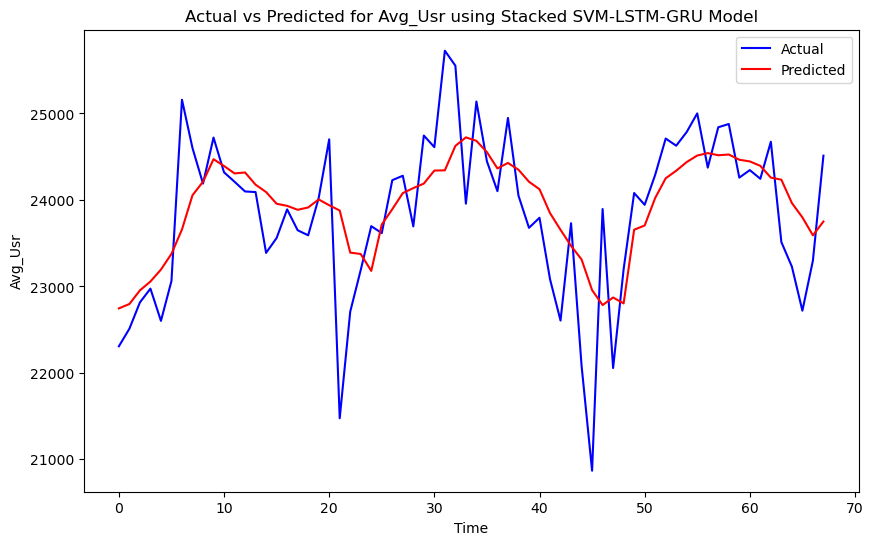

In [15]:
# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# SVM Model Prediction
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

svm_model = SVR(kernel='rbf', C=1, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

# Predict with SVM
train_predict_svm = svm_model.predict(X_train_svm)
test_predict_svm = svm_model.predict(X_test_svm)

# Prepare the data for LSTM/GRU hybrid
def create_dataset_hybrid(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        # Combine original time series and SVM predictions as features
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Create dataset for LSTM using SVM predictions
X_train_lstm, y_train_lstm = create_dataset_hybrid(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_hybrid(test_predict_svm, test, look_back=look_back)

# Reshape input data for LSTM (samples, timesteps, features)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Function to build and train LSTM and GRU models
def build_lstm_gru_model(input_shape, lstm_units, gru_units, dropout_rate):
    model = Sequential()
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(GRU(gru_units, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Loop through different hyperparameter configurations
best_mse = float('inf')
best_params = {}
best_model = None

for lstm_units in [50, 100]:
    for gru_units in [50, 100]:
        for dropout_rate in [0.2, 0.3]:
            for batch_size in [32, 64]:
                for epochs in [50, 100]:
                    print(f'Training with LSTM units={lstm_units}, GRU units={gru_units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}')
                    model = build_lstm_gru_model((look_back, 2), lstm_units, gru_units, dropout_rate)
                    model.fit(X_train_lstm, y_train_lstm, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)
                    
                    # Predict
                    test_predict = model.predict(X_test_lstm)
                    
                    # Calculate MSE
                    mse = mean_squared_error(y_test_lstm, test_predict)
                    print(f'MSE: {mse}')
                    
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'lstm_units': lstm_units, 'gru_units': gru_units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs}
                        best_model = model

print(f'Best MSE: {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test_lstm)

# Invert predictions and actual values back to original scale
best_test_predict = scaler.inverse_transform(best_test_predict)
y_test_lstm = scaler.inverse_transform([y_test_lstm])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm[0], label='Actual', color='blue')
plt.plot(best_test_predict, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for Avg_Usr using Stacked SVM-LSTM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr')
plt.legend()
plt.show()

Training SVM with kernel=linear, C=0.1, gamma=scale
MSE for SVM: 0.007014629818826911
Training SVM with kernel=linear, C=0.1, gamma=auto
MSE for SVM: 0.007014629818826911
Training SVM with kernel=linear, C=1, gamma=scale
MSE for SVM: 0.005632253323588096
Training SVM with kernel=linear, C=1, gamma=auto
MSE for SVM: 0.005632253323588096
Training SVM with kernel=linear, C=10, gamma=scale
MSE for SVM: 0.005565494518045634
Training SVM with kernel=linear, C=10, gamma=auto
MSE for SVM: 0.005565494518045634
Training SVM with kernel=rbf, C=0.1, gamma=scale
MSE for SVM: 0.009402962084865782
Training SVM with kernel=rbf, C=0.1, gamma=auto
MSE for SVM: 0.011126600625618318
Training SVM with kernel=rbf, C=1, gamma=scale
MSE for SVM: 0.008869347452998402
Training SVM with kernel=rbf, C=1, gamma=auto
MSE for SVM: 0.0067182374601026315
Training SVM with kernel=rbf, C=10, gamma=scale
MSE for SVM: 0.012707958067213561
Training SVM with kernel=rbf, C=10, gamma=auto
MSE for SVM: 0.005574595874541555
Tra

Epoch 16/100
9/9 [==============================] - 0s 16ms/step - loss: 0.0046 - val_loss: 0.0020
Epoch 17/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0046 - val_loss: 0.0019
Epoch 18/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0043 - val_loss: 0.0020
Epoch 19/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 20/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0037 - val_loss: 0.0021
Epoch 21/100
9/9 [==============================] - 0s 19ms/step - loss: 0.0037 - val_loss: 0.0019
Epoch 22/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0037 - val_loss: 0.0019
Epoch 23/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0039 - val_loss: 0.0019
Epoch 24/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0038 - val_loss: 0.0019
Epoch 25/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0040 - val_loss: 0.0019
Epoch 26/1

Epoch 99/100
9/9 [==============================] - 0s 10ms/step - loss: 0.0034 - val_loss: 0.0013
Epoch 100/100
3/3 [==============================] - 1s 3ms/step
MSE: 0.003535008929940906
Training LSTM-GRU with LSTM units=50, GRU units=50, dropout_rate=0.2, batch_size=64, epochs=50
Epoch 1/50
5/5 [==============================] - 13s 423ms/step - loss: 0.1923 - val_loss: 0.1668
Epoch 2/50
5/5 [==============================] - 0s 17ms/step - loss: 0.0956 - val_loss: 0.0582
Epoch 3/50
5/5 [==============================] - 0s 13ms/step - loss: 0.0329 - val_loss: 0.0033
Epoch 4/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0198 - val_loss: 0.0068
Epoch 5/50
5/5 [==============================] - 0s 15ms/step - loss: 0.0293 - val_loss: 0.0031
Epoch 6/50
5/5 [==============================] - 0s 16ms/step - loss: 0.0186 - val_loss: 0.0030
Epoch 7/50
5/5 [==============================] - 0s 14ms/step - loss: 0.0149 - val_loss: 0.0112
Epoch 8/50
5/5 [==================

Epoch 29/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0047 - val_loss: 0.0018
Epoch 30/100
5/5 [==============================] - 0s 21ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 31/100
5/5 [==============================] - 0s 30ms/step - loss: 0.0050 - val_loss: 0.0022
Epoch 32/100
5/5 [==============================] - 0s 28ms/step - loss: 0.0043 - val_loss: 0.0019
Epoch 33/100
5/5 [==============================] - 0s 25ms/step - loss: 0.0046 - val_loss: 0.0037
Epoch 34/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0088 - val_loss: 0.0159
Epoch 35/100
5/5 [==============================] - 0s 21ms/step - loss: 0.0113 - val_loss: 0.0029
Epoch 36/100
5/5 [==============================] - 0s 24ms/step - loss: 0.0046 - val_loss: 0.0039
Epoch 37/100
5/5 [==============================] - 0s 25ms/step - loss: 0.0069 - val_loss: 0.0018
Epoch 38/100
5/5 [==============================] - 0s 28ms/step - loss: 0.0044 - val_loss: 0.0038
Epoch 39/1

9/9 [==============================] - 0s 15ms/step - loss: 0.0045 - val_loss: 0.0021
Epoch 42/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0039 - val_loss: 0.0017
Epoch 43/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 44/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 45/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0075 - val_loss: 0.0017
Epoch 46/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0052 - val_loss: 0.0024
Epoch 47/100
9/9 [==============================] - 0s 16ms/step - loss: 0.0036 - val_loss: 0.0016
Epoch 48/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0038 - val_loss: 0.0019
Epoch 49/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0040 - val_loss: 0.0018
Epoch 50/100
9/9 [==============================] - 0s 18ms/step - loss: 0.0039 - val_loss: 0.0016
Epoch 51/100
9/9 [=====

...

Epoch 14/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0038 - val_loss: 0.0017
Epoch 15/100
9/9 [==============================] - 0s 25ms/step - loss: 0.0036 - val_loss: 0.0020
Epoch 16/100
9/9 [==============================] - 0s 24ms/step - loss: 0.0037 - val_loss: 0.0017
Epoch 17/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0034 - val_loss: 0.0017
Epoch 18/100
9/9 [==============================] - 0s 23ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 19/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0032 - val_loss: 0.0017
Epoch 20/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 21/100
9/9 [==============================] - 0s 21ms/step - loss: 0.0031 - val_loss: 0.0020
Epoch 22/100
9/9 [==============================] - 0s 22ms/step - loss: 0.0039 - val_loss: 0.0023
Epoch 23/100
9/9 [==============================] - 0s 33ms/step - loss: 0.0036 - val_loss: 0.0021
Epoch 24/1

Epoch 97/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0024 - val_loss: 0.0012
Epoch 98/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0025 - val_loss: 0.0015
Epoch 99/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0023 - val_loss: 0.0012
Epoch 100/100
3/3 [==============================] - 2s 6ms/step
MSE: 0.0033312805183702515
Training LSTM-GRU with LSTM units=100, GRU units=150, dropout_rate=0.2, batch_size=64, epochs=50
Epoch 1/50
5/5 [==============================] - 13s 896ms/step - loss: 0.2047 - val_loss: 0.0860
Epoch 2/50
5/5 [==============================] - 0s 29ms/step - loss: 0.0362 - val_loss: 0.0095
Epoch 3/50
5/5 [==============================] - 0s 35ms/step - loss: 0.0421 - val_loss: 0.0108
Epoch 4/50
5/5 [==============================] - 0s 33ms/step - loss: 0.0209 - val_loss: 0.0060
Epoch 5/50
5/5 [==============================] - 0s 32ms/step - loss: 0.0144 - val_loss: 0.0183
Epoch 6/50
5/5 [===========

Epoch 27/100
5/5 [==============================] - 0s 26ms/step - loss: 0.0035 - val_loss: 0.0017
Epoch 28/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0034 - val_loss: 0.0017
Epoch 29/100
5/5 [==============================] - 0s 24ms/step - loss: 0.0037 - val_loss: 0.0017
Epoch 30/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0035 - val_loss: 0.0017
Epoch 31/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 32/100
5/5 [==============================] - 0s 23ms/step - loss: 0.0036 - val_loss: 0.0027
Epoch 33/100
5/5 [==============================] - 0s 23ms/step - loss: 0.0032 - val_loss: 0.0018
Epoch 34/100
5/5 [==============================] - 0s 23ms/step - loss: 0.0041 - val_loss: 0.0016
Epoch 35/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0037 - val_loss: 0.0024
Epoch 36/100
5/5 [==============================] - 0s 21ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 37/1

9/9 [==============================] - 0s 21ms/step - loss: 0.0045 - val_loss: 0.0018
Epoch 9/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0039 - val_loss: 0.0017
Epoch 10/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0046 - val_loss: 0.0018
Epoch 11/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0053 - val_loss: 0.0023
Epoch 12/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 13/50
9/9 [==============================] - 0s 23ms/step - loss: 0.0043 - val_loss: 0.0030
Epoch 14/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0046 - val_loss: 0.0017
Epoch 15/50
9/9 [==============================] - 0s 24ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 16/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0036 - val_loss: 0.0017
Epoch 17/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0041 - val_loss: 0.0022
Epoch 18/50
9/9 [================

5/5 [==============================] - 0s 31ms/step - loss: 0.0042 - val_loss: 0.0017
Epoch 21/50
5/5 [==============================] - 0s 32ms/step - loss: 0.0041 - val_loss: 0.0018
Epoch 22/50
5/5 [==============================] - 0s 34ms/step - loss: 0.0035 - val_loss: 0.0022
Epoch 23/50
5/5 [==============================] - 0s 30ms/step - loss: 0.0040 - val_loss: 0.0017
Epoch 24/50
5/5 [==============================] - 0s 36ms/step - loss: 0.0046 - val_loss: 0.0027
Epoch 25/50
5/5 [==============================] - 0s 34ms/step - loss: 0.0041 - val_loss: 0.0019
Epoch 26/50
5/5 [==============================] - 0s 34ms/step - loss: 0.0042 - val_loss: 0.0023
Epoch 27/50
5/5 [==============================] - 0s 36ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 28/50
5/5 [==============================] - 0s 37ms/step - loss: 0.0037 - val_loss: 0.0018
Epoch 29/50
5/5 [==============================] - 0s 36ms/step - loss: 0.0036 - val_loss: 0.0018
Epoch 30/50
5/5 [===============

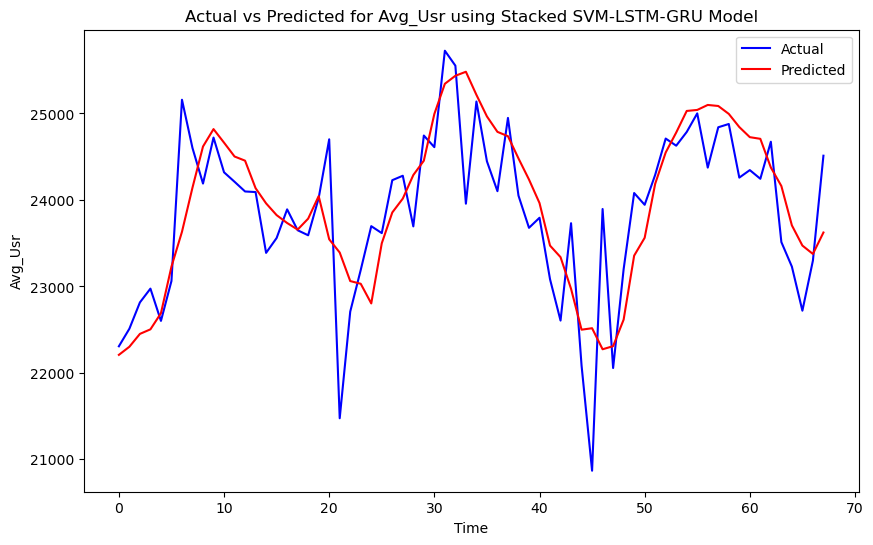

In [16]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for SVM
def create_dataset_svm(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), 0])  # Flatten to 1D array for SVM
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

# Preparing data for 'Avg_Usr'
feature = 'Avg_Usr'
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])

# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# SVM Model Prediction
look_back = 3
X_train_svm, y_train_svm = create_dataset_svm(train, look_back=look_back)
X_test_svm, y_test_svm = create_dataset_svm(test, look_back=look_back)

# Hyperparameter search for SVM units
best_mse_svm = float('inf')
best_svm_params = {}

# SVM hyperparameters to tune
svm_kernels = ['linear', 'rbf', 'poly']  # Different kernel functions
svm_C_values = [0.1, 1, 10]  # Regularization parameter (penalty)
svm_gamma_values = ['scale', 'auto']  # Kernel coefficient

for kernel in svm_kernels:
    for C in svm_C_values:
        for gamma in svm_gamma_values:
            print(f"Training SVM with kernel={kernel}, C={C}, gamma={gamma}")
            svm_model = SVR(kernel=kernel, C=C, gamma=gamma)
            svm_model.fit(X_train_svm, y_train_svm)

            # Predict and calculate MSE
            train_predict_svm = svm_model.predict(X_train_svm)
            test_predict_svm = svm_model.predict(X_test_svm)

            mse_svm = mean_squared_error(y_test_svm, test_predict_svm)
            print(f"MSE for SVM: {mse_svm}")

            if mse_svm < best_mse_svm:
                best_mse_svm = mse_svm
                best_svm_params = {'kernel': kernel, 'C': C, 'gamma': gamma}
                best_svm_model = svm_model

print(f'Best SVM params: {best_svm_params}, MSE: {best_mse_svm}')

# Prepare the data for LSTM/GRU hybrid using best SVM predictions
def create_dataset_hybrid(svm_predictions, original_data, look_back=1):
    X, Y = [], []
    for i in range(len(svm_predictions) - look_back):
        feature_set = np.hstack((original_data[i:(i + look_back)], svm_predictions[i:(i + look_back)].reshape(-1, 1)))
        X.append(feature_set)
        Y.append(original_data[i + look_back, 0])
    return np.array(X), np.array(Y)

# Create dataset for LSTM using SVM predictions
X_train_lstm, y_train_lstm = create_dataset_hybrid(train_predict_svm, train, look_back=look_back)
X_test_lstm, y_test_lstm = create_dataset_hybrid(test_predict_svm, test, look_back=look_back)

# Reshape input data for LSTM (samples, timesteps, features)
X_train_lstm = np.reshape(X_train_lstm, (X_train_lstm.shape[0], X_train_lstm.shape[1], 2))
X_test_lstm = np.reshape(X_test_lstm, (X_test_lstm.shape[0], X_test_lstm.shape[1], 2))

# Function to build and train LSTM and GRU models
def build_lstm_gru_model(input_shape, lstm_units, gru_units, dropout_rate):
    model = Sequential()
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(GRU(gru_units, return_sequences=False))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# Experiment with different LSTM, GRU units, and dropout rates
best_mse = float('inf')
best_params = {}
best_model = None

# Loop through different configurations
for lstm_units in [50, 100]:
    for gru_units in [50, 100, 150]:
        for dropout_rate in [0.2, 0.3]:
            for batch_size in [32, 64]:
                for epochs in [50, 100]:
                    print(f"Training LSTM-GRU with LSTM units={lstm_units}, GRU units={gru_units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}")
                    model = build_lstm_gru_model((look_back, 2), lstm_units, gru_units, dropout_rate)
                    model.fit(X_train_lstm, y_train_lstm, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1)

                    # Predict
                    test_predict = model.predict(X_test_lstm)
                    
                    # Calculate MSE
                    mse = mean_squared_error(y_test_lstm, test_predict)
                    print(f'MSE: {mse}')

                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'lstm_units': lstm_units, 'gru_units': gru_units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs}
                        best_model = model

print(f'Best MSE: {best_mse} with params: {best_params}')

# Predict with the best model
best_test_predict = best_model.predict(X_test_lstm)

# Invert predictions and actual values back to original scale
best_test_predict = scaler.inverse_transform(best_test_predict)
y_test_lstm = scaler.inverse_transform([y_test_lstm])

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_lstm[0], label='Actual', color='blue')
plt.plot(best_test_predict, label='Predicted', color='red')
plt.title(f'Actual vs Predicted for Avg_Usr using Stacked SVM-LSTM-GRU Model')
plt.xlabel('Time')
plt.ylabel('Avg_Usr')
plt.legend()
plt.show()

In [6]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [7]:
# Define features and target
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train LSTM model
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'adam'
look_back = 3

# Dictionary to store MSE and R-squared for each feature or combination
evaluation_scores = []

# Step 1: Train LSTM model with each feature individually
for feature in selected_features:
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    evaluation_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Step 2: Train LSTM model with all 10 features combined
selected_data = data[[target_feature] + selected_features]
data_scaled = scaler.fit_transform(selected_data)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

X_train, y_train = create_dataset(train_data, look_back=look_back)
X_test, y_test = create_dataset(test_data, look_back=look_back)

# Reshape input data to 3D (samples, timesteps, features) for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Train LSTM model
model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

# Ensure proper shape for evaluation
y_test = y_test.flatten()
test_predict = test_predict.flatten()

# Calculate MSE and R-squared
if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
    mse = mean_squared_error(y_test, test_predict)
    r_squared = r2_score(y_test, test_predict)
else:
    mse = np.nan
    r_squared = np.nan

evaluation_scores.append({"Features": "All 10 Features Combined", "MSE": mse, "R-squared": r_squared})

# Convert results to DataFrame and sort by MSE
evaluation_df = pd.DataFrame(evaluation_scores)
evaluation_df = evaluation_df.sort_values(by="MSE").reset_index(drop=True)

# Display the table
print(evaluation_df)

3/3 [==============================] - 1s 5ms/step
                    Features       MSE  R-squared
0                 DL_LATENCY  0.006145   0.172928
1          DL_PACK_LOSS_RATE  0.006411   0.137066
2                       CSSR  0.006990   0.059205
3                    Max_Usr  0.007086   0.046164
4              DL_TRAFFIC_MB  0.008447  -0.136944
5         DL_QPSK_PROPORTION  0.009507  -0.279665
6              Avg_Usr_TP_UL  0.011766  -0.583766
7   All 10 Features Combined  0.013318  -0.792546
8              Avg_Usr_TP_DL  0.016043  -1.159408
9       DL_256QAM_PROPORTION  0.025168  -2.387603
10               S1_SIG_SUCC  0.039668  -4.339336


In [8]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import ParameterGrid

# Define features and target
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train LSTM model
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Parameters
units = 50
dropout_rate = 0.4
batch_size = 64
epochs = 50
optimizer = 'adam'
look_back = 3

# Dictionary to store MSE and R-squared for each feature or combination
evaluation_scores = []

# Step 1: Train LSTM model with each feature individually
for feature in selected_features:
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    evaluation_scores.append({"Features": feature, "MSE": mse, "R-squared": r_squared})

# Sort features based on MSE to determine order of addition
evaluation_df = pd.DataFrame(evaluation_scores).sort_values(by="MSE").reset_index(drop=True)

# Step 2: Incrementally add features based on MSE ranking
final_scores = []
best_features = []

for index, row in evaluation_df.iterrows():
    best_features.append(row["Features"])
    selected_data = data[[target_feature] + best_features]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    X_train, y_train = create_dataset(train_data, look_back=look_back)
    X_test, y_test = create_dataset(test_data, look_back=look_back)

    # Reshape input data to 3D (samples, timesteps, features) for LSTM input
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Train LSTM model
    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)

    # Ensure proper shape for evaluation
    y_test = y_test.flatten()
    test_predict = test_predict.flatten()

    # Calculate MSE and R-squared
    if not np.isnan(y_test).any() and not np.isnan(test_predict).any():
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)
    else:
        mse = np.nan
        r_squared = np.nan

    final_scores.append({"Features": ", ".join(best_features), "MSE": mse, "R-squared": r_squared})

# Convert final results to DataFrame
final_evaluation_df = pd.DataFrame(final_scores)

# Display the final table
print(final_evaluation_df)


3/3 [==============================] - 1s 3ms/step
                                            Features       MSE  R-squared
0                                      DL_TRAFFIC_MB  0.005642   0.240613
1                  DL_TRAFFIC_MB, DL_QPSK_PROPORTION  0.009033  -0.215873
2            DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR  0.009531  -0.282881
3   DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_Usr  0.015968  -1.149332
4  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.010260  -0.380976
5  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.022842  -2.074547
6  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.026361  -2.548249
7  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.012082  -0.626219
8  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.016598  -1.234051
9  DL_TRAFFIC_MB, DL_QPSK_PROPORTION, CSSR, Max_U...  0.066281  -7.921421


In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import ParameterGrid

# Define features and target
selected_features = [
    'Avg_Usr_TP_DL', 'Avg_Usr_TP_UL', 'CSSR', 
    'DL_256QAM_PROPORTION', 'DL_LATENCY', 'DL_PACK_LOSS_RATE', 
    'DL_QPSK_PROPORTION', 'DL_TRAFFIC_MB', 'Max_Usr', 
    'S1_SIG_SUCC'
]
target_feature = 'Avg_Usr'

# Normalize all features
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data[[target_feature] + selected_features])

# Split data into train and test sets (80% train, 20% test)
train_size = int(len(data_scaled) * 0.8)
train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset[i:(i + look_back), :])
        Y.append(dataset[i + look_back, 0])  # Target is the first column after scaling
    return np.array(X), np.array(Y)

# Function to train LSTM model
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=0, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history

# Define hyperparameter grid
param_grid = {
    'units': [50, 100],
    'dropout_rate': [0.2, 0.4],
    'batch_size': [32, 64],
    'epochs': [50, 100],
    'optimizer': ['adam', 'rmsprop'],
    'look_back': [3, 5]
}

# Create a grid of parameters
parameter_combinations = list(ParameterGrid(param_grid))

# Dictionary to store best evaluation metrics
best_model_metrics = {
    "Features": None,
    "MSE": float('inf'),
    "R-squared": float('-inf'),
    "Params": None
}

# Step 1: Train LSTM model with each feature individually
for feature in selected_features:
    selected_data = data[[target_feature, feature]]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    for params in parameter_combinations:
        X_train, y_train = create_dataset(train_data, look_back=params['look_back'])
        X_test, y_test = create_dataset(test_data, look_back=params['look_back'])

        # Reshape input data to 3D (samples, timesteps, features) for LSTM input
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

        # Train LSTM model
        model, test_predict, history = train_lstm_model(
            X_train, y_train, X_test, y_test,
            units=params['units'],
            dropout_rate=params['dropout_rate'],
            batch_size=params['batch_size'],
            epochs=params['epochs'],
            optimizer=params['optimizer']
        )

        # Ensure proper shape for evaluation
        y_test = y_test.flatten()
        test_predict = test_predict.flatten()

        # Calculate MSE and R-squared
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)

        if mse < best_model_metrics['MSE']:
            best_model_metrics.update({
                "Features": feature,
                "MSE": mse,
                "R-squared": r_squared,
                "Params": params
            })

# Step 2: Incrementally add features based on best performance
evaluation_scores = []
best_features = []

for feature in selected_features:
    best_features.append(feature)
    selected_data = data[[target_feature] + best_features]
    data_scaled = scaler.fit_transform(selected_data)
    train_data, test_data = data_scaled[:train_size], data_scaled[train_size:]

    for params in parameter_combinations:
        X_train, y_train = create_dataset(train_data, look_back=params['look_back'])
        X_test, y_test = create_dataset(test_data, look_back=params['look_back'])

        # Reshape input data to 3D (samples, timesteps, features) for LSTM input
        X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], X_train.shape[2]))
        X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], X_test.shape[2]))

        # Train LSTM model
        model, test_predict, history = train_lstm_model(
            X_train, y_train, X_test, y_test,
            units=params['units'],
            dropout_rate=params['dropout_rate'],
            batch_size=params['batch_size'],
            epochs=params['epochs'],
            optimizer=params['optimizer']
        )

        # Ensure proper shape for evaluation
        y_test = y_test.flatten()
        test_predict = test_predict.flatten()

        # Calculate MSE and R-squared
        mse = mean_squared_error(y_test, test_predict)
        r_squared = r2_score(y_test, test_predict)

        evaluation_scores.append({
            "Features": ", ".join(best_features),
            "MSE": mse,
            "R-squared": r_squared,
            "Params": params
        })

# Convert final results to DataFrame
final_evaluation_df = pd.DataFrame(evaluation_scores)

# Display the final table
print(final_evaluation_df)


3/3 [==============================] - 1s 0s/step


3/3 [==============================] - 1s 5ms/step


3/3 [==============================] - 1s 0s/step


3/3 [==============================] - 2s 8ms/step


3/3 [==============================] - 1s 8ms/step


3/3 [==============================] - 1s 8ms/step


3/3 [==============================] - 2s 8ms/step


3/3 [==============================] - 4s 8ms/step
                                              Features       MSE  R-squared  \
0                                        Avg_Usr_TP_DL  0.012691  -0.708175   
1                                        Avg_Usr_TP_DL  0.015066  -1.027948   
2                                        Avg_Usr_TP_DL  0.027594  -2.714194   
3                                        Avg_Usr_TP_DL  0.057298  -6.712360   
4                                        Avg_Usr_TP_DL  0.033457  -3.712476   
..                                                 ...       ...        ...   
635  Avg_Usr_TP_DL, Avg_Usr_TP_UL, CSSR, DL_256QAM_...  0.009791  -0.317854   
636  Avg_Usr_TP_DL, Avg_Usr_TP_UL, CSSR, DL_256QAM_...  0.072688  -9.238324   
637  Avg_Usr_TP_DL, Avg_Usr_TP_UL, CSSR, DL_256QAM_...  0.019279  -1.715552   
638  Avg_Usr_TP_DL, Avg_Usr_TP_UL, CSSR, DL_256QAM_...  0.013670  -0.925407   
639  Avg_Usr_TP_DL, Avg_Usr_TP_UL, CSSR, DL_256QAM_...  0.028348  -2.992949   



In [10]:
final_evaluation_df.to_excel("evaluation_results.xlsx", index=False) 